In [1]:
from google.cloud import bigquery
from google.cloud import aiplatform
import bigframes.pandas as bpd
import pandas as pd
from vertexai.language_models._language_models import TextGenerationModel
from vertexai.generative_models import GenerativeModel
from bigframes.ml.cluster import KMeans
from bigframes.ml.model_selection import train_test_split

In [2]:
project_id = 'qwiklabs-gcp-03-aa56001d8b8b'
dataset_name = "ecommerce"
model_name = "customer_segmentation_model"
table_name = "customer_stats"
location = "us-central1"
client = bigquery.Client(project=project_id)
aiplatform.init(project=project_id, location=location)

In [3]:
%%bigquery
CREATE OR REPLACE TABLE ecommerce.customer_stats AS
SELECT
  user_id,
  DATE_DIFF(CURRENT_DATE(), CAST(MAX(order_created_date) AS DATE), day) AS days_since_last_order, ---RECENCY
  COUNT(order_id) AS count_orders, --FREQUENCY
  AVG(sale_price) AS average_spend --MONETARY
  FROM (
      SELECT
        user_id,
        order_id,
        sale_price,
        created_at AS order_created_date
        FROM `bigquery-public-data.thelook_ecommerce.order_items`
        WHERE
        created_at
            BETWEEN '2022-01-01' AND '2023-01-01'
  )
GROUP BY user_id;

Query is running:   0%|          |

""


In [4]:
# prompt: Convert the table ecommerce.customer_stats to a bigframes dataframe and show the top 10 records

import bigframes.pandas as bpd

# Read the BigQuery table 'qwiklabs-gcp-03-aa56001d8b8b.ecommerce.customer_stats' into a BigFrames DataFrame.
# The bpd.read_gbq function is used to load data directly from a BigQuery table.
df = bpd.read_gbq("qwiklabs-gcp-03-aa56001d8b8b.ecommerce.customer_stats")

# Select the first 10 rows of the DataFrame.
# The .head(10) method returns the first 10 rows of the DataFrame.
result = df.head(10)

In [5]:
result

,user_id,days_since_last_order,count_orders,average_spend
0,46199,1280,3,50.840001
1,97067,1415,1,45.0
2,24184,1505,1,25.0
3,48853,1258,4,29.015
4,54613,1217,1,55.0
5,84043,1284,1,29.99
6,79288,1155,2,195.995001
7,41728,1470,1,74.5
8,42575,1439,1,90.0
9,71156,1377,4,63.234999


In [6]:
# prompt: 1. Split the DataFrame df into training and testing sets using train_test_split with a test size of 0.2 and random_state=42 for reproducibility. Store the splits as df_train and df_test. 2. Create a KMeans clustering model using bigframes.ml.cluster.KMeans with 5 clusters (note: do not include random_state since it's unsupported). 3. Fit the KMeans model on the training data (df_train). 4. Save the trained model to BigQuery using the to_gbq method, specifying the model path as project_id.dataset_name.model_name. 5. Store the trained model object in a variable named result.

# 1. Split the DataFrame df into training and testing sets.
# The train_test_split function from bigframes.ml.model_selection is used to divide the DataFrame.
# It takes the DataFrame 'df' as input, along with 'test_size' to specify the proportion of the dataset to include in the test split,
# and 'random_state' for reproducibility of the split.
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

# 2. Create a KMeans clustering model.
# An instance of KMeans from bigframes.ml.cluster is created.
# The 'n_clusters' parameter is set to 5, indicating that the model should find 5 clusters.
kmeans_model = KMeans(n_clusters=5)

# 3. Fit the KMeans model on the training data.
# The 'fit' method trains the KMeans model using the features in 'df_train'.
# The columns 'days_since_last_order', 'count_orders', and 'average_spend' are used as features for clustering.
kmeans_model.fit(df_train[['days_since_last_order', 'count_orders', 'average_spend']])

# 4. Save the trained model to BigQuery.
# The 'to_gbq' method saves the trained KMeans model to a specified BigQuery location.
# The model path is constructed using the project_id, dataset_name, and model_name variables.
kmeans_model.to_gbq(f"{project_id}.{dataset_name}.{model_name}")

# 5. Store the trained model object in a variable named result.
# The 'result' variable now holds the trained KMeans model object.
result = kmeans_model

In [7]:
result

KMeans(n_clusters=5)

In [8]:
# prompt: 1. Call the K-means prediction model on the df dataframe, and store the results as predictions_df and show the first 10 records.

predictions_df = kmeans_model.predict(df[['days_since_last_order', 'count_orders', 'average_spend']])
result = predictions_df.head(10)

In [9]:
result

,CENTROID_ID,NEAREST_CENTROIDS_DISTANCE,days_since_last_order,count_orders,average_spend
0,1,"[{'CENTROID_ID': 1, 'DISTANCE': 0.668646376012...",1280,3,50.840001
1,3,"[{'CENTROID_ID': 3, 'DISTANCE': 0.266581266858...",1415,1,45.0
2,3,"[{'CENTROID_ID': 3, 'DISTANCE': 0.985468429756...",1505,1,25.0
3,1,"[{'CENTROID_ID': 1, 'DISTANCE': 0.689419221447...",1258,4,29.015
4,4,"[{'CENTROID_ID': 4, 'DISTANCE': 0.368685522368...",1217,1,55.0
5,4,"[{'CENTROID_ID': 4, 'DISTANCE': 0.644218947902...",1284,1,29.99
6,5,"[{'CENTROID_ID': 5, 'DISTANCE': 1.690422709036...",1155,2,195.995001
7,3,"[{'CENTROID_ID': 3, 'DISTANCE': 0.784513763906...",1470,1,74.5
8,3,"[{'CENTROID_ID': 3, 'DISTANCE': 0.857273664615...",1439,1,90.0
9,1,"[{'CENTROID_ID': 1, 'DISTANCE': 0.937417800056...",1377,4,63.234999


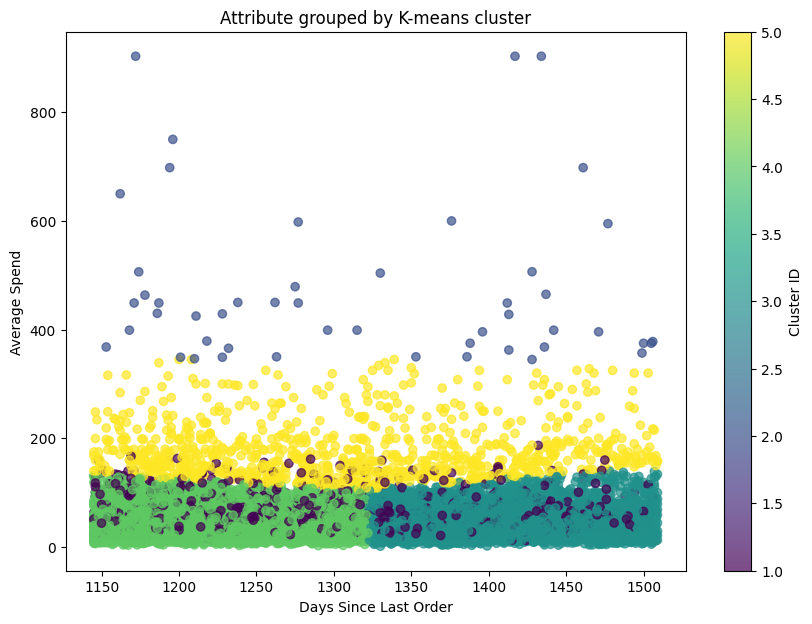

In [10]:
# prompt: 1. Using predictions_df, and matplotlib, generate a scatterplot. 2. On the x-axis of the scatterplot, display days_since_last_order and on the y-axis, display average_spend from predictions_df. 3. Color by cluster. 4. The chart should be titled "Attribute grouped by K-means cluster."

import matplotlib.pyplot as plt

# Create the scatterplot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    predictions_df['days_since_last_order'],
    predictions_df['average_spend'],
    c=predictions_df['CENTROID_ID'],  # Color by cluster
    cmap='viridis',  # Colormap for clusters
    alpha=0.7
)

# Add labels and title
plt.xlabel('Days Since Last Order')
plt.ylabel('Average Spend')
plt.title('Attribute grouped by K-means cluster')

# Add a colorbar to show cluster IDs
plt.colorbar(scatter, label='Cluster ID')

# Display the plot
plt.show()

In [11]:
query = """
SELECT
 CONCAT('cluster ', CAST(centroid_id as STRING)) as centroid,
 average_spend,
 count_orders,
 days_since_last_order
FROM (
 SELECT centroid_id, feature, ROUND(numerical_value, 2) as value
 FROM ML.CENTROIDS(MODEL `{0}.{1}`)
)
PIVOT (
 SUM(value)
 FOR feature IN ('average_spend',  'count_orders', 'days_since_last_order')
)
ORDER BY centroid_id
""".format(dataset_name, model_name)

df_centroid = client.query(query).to_dataframe()
df_centroid.head()

,centroid,average_spend,count_orders,days_since_last_order
0,cluster 1,57.79,3.64,1287.52
1,cluster 2,509.04,1.16,1318.84
2,cluster 3,45.96,1.26,1413.64
3,cluster 4,43.68,1.28,1229.24
4,cluster 5,181.77,1.23,1309.05


In [12]:
df_query = client.query(query).to_dataframe()
df_query.to_string(header=False, index=False)

cluster_info = []
for i, row in df_query.iterrows():
 cluster_info.append("{0}, average spend ${2}, count of orders per person {1}, days since last order {3}"
  .format(row["centroid"], row["count_orders"], row["average_spend"], row["days_since_last_order"]) )

cluster_info = (str.join("\n", cluster_info))
print(cluster_info)

cluster 1, average spend $57.79, count of orders per person 3.64, days since last order 1287.52
cluster 2, average spend $509.04, count of orders per person 1.16, days since last order 1318.84
cluster 3, average spend $45.96, count of orders per person 1.26, days since last order 1413.64
cluster 4, average spend $43.68, count of orders per person 1.28, days since last order 1229.24
cluster 5, average spend $181.77, count of orders per person 1.23, days since last order 1309.05


In [13]:
model = GenerativeModel("gemini-2.5-pro")

prompt = f"""
You're a creative brand strategist, given the following clusters, come up with \
creative brand persona, a catchy title, and next marketing action, \
explained step by step. Identify the cluster number, the title of the person, a persona for them and the next marketing step.

Clusters:
{cluster_info}

For each Cluster:
* Title:
* Persona:
* Next marketing step:
"""

responses = model.generate_content(
   prompt,
   generation_config={
      "temperature": 0.1,
      "max_output_tokens": 4000,
      "top_p": 1.0,
      "top_k": 40,
   }
)

print(responses.text)

/usr/local/lib/python3.12/dist-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


Of course. As a creative brand strategist, my first observation is that all these clusters represent **lapsed customers**, with the last order placed over three years ago for every single group. This is a critical insight. Our entire strategy must be focused on **reactivation and winning back trust**, not standard marketing.

Here is the strategic breakdown for each cluster.

***

### **Cluster 1**

*   **Data:** Average Spend $57.79, Orders Per Person 3.64, Days Since Last Order 1287.52
*   **Title:** **The Lost Loyalists**
*   **Persona:** Meet **Eleanor**. For a time, we were her go-to brand. She didn't just buy once; she came back again and again, integrating our products into her life. Her average spend wasn't massive, but her loyalty was priceless. She was a true fan, the kind of customer who builds a brand. But something happened. We either changed, discontinued her favorite product, or simply stopped speaking to her in a way that mattered. She's since moved on, and her silence 